In [ ]:
import pyEDM
import pandas as pd
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt

random.seed(42)

combined = pd.read_csv('../data/processed_ifcb158.csv')

In [ ]:
# MVE method using site 158 (del mar mooring in the san diego bay) as the target

In [2]:
# looking at missing data
w = pd.to_datetime(combined['date'].astype(str),format='%Y%m%d')

full_dates = pd.date_range(start=w.min(),end=w.max(),freq='D')
observed_dates = w
missing_dates = full_dates.difference(observed_dates)

print("Total days in range:", len(full_dates))
print("Total days with data:", len(observed_dates))
print("Days with true missing data:", len(missing_dates))

Total days in range: 1672
Total days with data: 996
Days with true missing data: 676


In [3]:
# top 20 features from paper + target variable + one additional taxa as predictor
features = [
    "Lpoly_expected_ml", "Area", "Biovolume", "MajorAxisLength",
    "MinorAxisLength", "Perimeter", "Orientation", "Eccentricity",
    "Solidity", "texture_uniformity", "texture_smoothness",
    "texture_average_gray_level", "texture_entropy",
    "texture_average_contrast", "H90", "H180", "Hflip",
    "Extent", "EquivDiameter", "ConvexArea", "ConvexPerimeter",
    "Pmicans_expected_ml" # add another taxa as a predictor
]

target = "Lpoly_expected_ml"
predictors = [col for col in features if col != target]

# process images features for MVE
df = combined[["date"] + features].copy()
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df = df.sort_values("date").set_index("date")
df = df.asfreq("D")

# fill missing values using ema
df_filled = df.copy()
for col in features:
    ema = df[col].ewm(span=30, adjust=False).mean()
    df_filled[col] = df[col].fillna(ema)

# normalize features
df_norm = df_filled.copy()
for col in features:
    mu = df_filled[col].mean()
    sigma = df_filled[col].std()
    df_norm[col] = (df_filled[col] - mu) / sigma

df_mv = df_norm.copy()

In [ ]:
# process environmental data
env = pd.read_csv("../data/environment_all.csv")

# could be relevant but too many missing values for ema imputation to be effective
env = env.drop(columns=[
    'fluorescent_dissolved_organic_matter_eco',
    'sea_water_turbidity_eco',
    'waterlevel_predicted_m',
    'mass_concentration_of_oxygen_in_sea_water_seaphox',
    'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water_seaphox',
    'fractional_saturation_of_oxygen_in_sea_water_seaphox',
    'sea_water_ph_reported_on_total_scale_seaphox_external'
])

env["date"] = pd.to_datetime(env["date"].astype(str), format="%Y%m%d")
env = env.sort_values("date").set_index("date")
env = env.asfreq("D")

env_features = env.columns.tolist()
env_filled = env.copy()

# fill missing values using ema
for col in env_features:
    ema = env[col].ewm(span=30, adjust=False).mean()
    env_filled[col] = env[col].fillna(ema)

# normalize features
df_norm = env_filled.copy()
for col in env_features:
    mu = env_filled[col].mean()
    sigma = env_filled[col].std()
    df_norm[col] = (env_filled[col] - mu) / sigma

df_env = df_norm.copy()

In [5]:
# align the two datasets on their common date range
common_start = max(df_mv.index.min(), df_env.index.min())
common_end = min(df_mv.index.max(), df_env.index.max())

df_mv = df_mv.loc[common_start:common_end]
df_env = df_env.loc[common_start:common_end]

df_all = df_mv.merge(df_env,left_index=True,right_index=True,how="inner")
df_all = df_all.reset_index()
df_all["t"] = np.arange(1, len(df_all) + 1)
df_all = df_all[["t"] + features + env_features]

df_mv = df_all[["t"] + features]
df_env = df_all[["t"] + env_features + [target]]

In [6]:
def one_simplex(df, target, features, E, Tp):
    # Randomly select 3 features (+ the target) for the simplex projection
    chosen_features = random.sample(features, E-1)
    columns = [target] + chosen_features
    columns_str = " ".join(columns) # has to be 'space separated' idk ????

    N = len(df)
    res = pyEDM.Simplex(
        dataFrame=df,
        columns=columns_str,
        target=target,
        E=E,
        tau=1,
        Tp=Tp,
        lib=f"1 {N}",
        pred=f"1 {N}"
    )

    obs = res["Observations"].to_numpy()
    pred = res["Predictions"].to_numpy()

    mask = np.isfinite(obs) & np.isfinite(pred)
    obs = obs[mask]
    pred = pred[mask]

    if len(obs) < 10 or np.std(obs) == 0 or np.std(pred) == 0:
        return np.nan, chosen_features

    rho = np.corrcoef(obs, pred)[0, 1]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    mae = np.mean(np.abs(obs - pred))
    return rho, rmse, mae, chosen_features

def multiview_big(df, target, features, Tp, E, n_trials=500):
    results = []

    for i in range(n_trials):
        rho, rmse, mae, chosen = one_simplex(df, target, features, E, Tp=Tp)

        results.append({
            "rho": rho,
            "rmse": rmse,
            "mae": mae,
            "features": chosen
        })

    return pd.DataFrame(results)

def multiview_yes(df_mv, target, predictors, E, n_trials=500):
    # wrapper main function
    x = df_mv[target].to_numpy()

    summary_rows = []
    feature_importance_by_tp = {}
    
    for Tp in range(1, 32):
        mv = multiview_big(df_mv, target, predictors, Tp, E, n_trials)

        acf = abs(pd.Series(x).autocorr(lag=Tp))
        mv["rho_eff"] = mv["rho"] - acf

        # summary stats
        summary_rows.append({
            "Tp": Tp,
            "rho_mean": mv["rho"].mean(),
            "acf": acf,
            "rho_eff_mean": mv["rho_eff"].mean(),
            "rmse_mean": mv["rmse"].mean(),
            "mae_mean": mv["mae"].mean(),
            "n_models": len(mv)
        })

        # feature importance (top 5%)
        top = mv.nlargest(int(0.05 * len(mv)), "rho_eff")

        counts = Counter()
        for feats in top["features"]:
            for f in feats:
                counts[f] += 1

        importance = pd.Series(counts) / len(top)
        feature_importance_by_tp[Tp] = importance.sort_values(ascending=False)
    
    return summary_rows, feature_importance_by_tp

In [7]:
def plot_tp(df, metric, ylabel, title,color="#0d7c8e",figsize=(3.5, 2)):
    plt.figure(figsize=figsize)
    plt.plot(df["Tp"], df[metric],marker="o",color=color)
    
    plt.xlabel("Prediction Interval (Tp)", fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.title(title, fontsize=10)

    plt.show()

In [8]:
summary_rows_com = []
feature_importance_by_tp_com = {}

summary_rows_com, feature_importance_by_tp_com = multiview_yes(df_all, target, predictors+env_features, E=4, n_trials=500)
summary_df_com = pd.DataFrame(summary_rows_com)
print(summary_df_com)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.961289  0.849674      0.111615   0.261466  0.072049       500
1    2  0.962006  0.713463      0.248543   0.260742  0.072462       500
2    3  0.957206  0.604001      0.353205   0.269083  0.078292       500
3    4  0.814667  0.556042      0.258626   0.520587  0.146580       500
4    5  0.727450  0.555332      0.172117   0.616207  0.172203       500
5    6  0.673743  0.533364      0.140378   0.666239  0.188480       500
6    7  0.640855  0.526771      0.114084   0.694685  0.202286       500
7    8  0.623111  0.534731      0.088380   0.711238  0.214797       500
8    9  0.617454  0.572062      0.045392   0.718730  0.221013       500
9   10  0.629915  0.610109      0.019806   0.709395  0.221181       500
10  11  0.656591  0.609137      0.047454   0.682354  0.220799       500
11  12  0.671911  0.567398      0.104513   0.667666  0.222219       500
12  13  0.675488  0.519189      0.156299   0.664693  0.223295   

In [9]:
importance_all_com = pd.concat(
    feature_importance_by_tp_com,
    names=["Tp", "Feature"]
).reset_index()

importance_all_com.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_com.head(7))

mean_importance_a = (
    importance_all_com
    .groupby("Feature")["Proportion"]
    .mean()
    .sort_values(ascending=False)
)
top_plot_a = mean_importance_a.head(15).sort_values()
print(top_plot_a.sort_values(ascending=False))

Feature
sea_water_pressure_ctd                                0.508148
waterlevel_verified_m                                 0.288889
sea_water_temperature_ctd                             0.257778
sea_water_electrical_conductivity_ctd                 0.225714
air_temp_c                                            0.214286
sea_water_sigma_t_ctd                                 0.191111
texture_uniformity                                    0.177143
mass_concentration_of_chlorophyll_in_sea_water_ctd    0.168696
Extent                                                0.148000
Solidity                                              0.137143
H180                                                  0.130000
baro_mb                                               0.126400
texture_entropy                                       0.124000
texture_smoothness                                    0.123200
MinorAxisLength                                       0.111667
Name: Proportion, dtype: float64


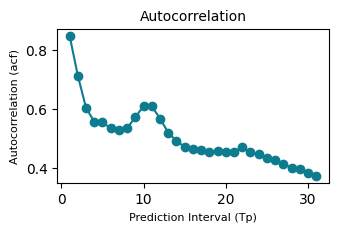

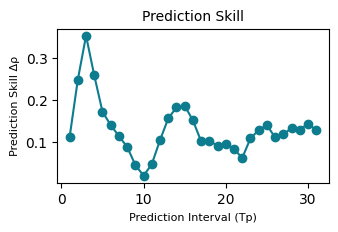

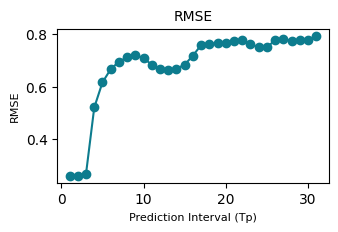

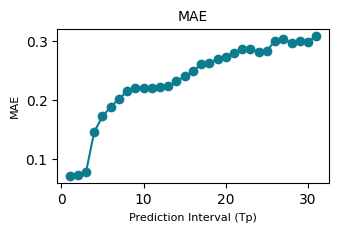

In [10]:
plot_tp(summary_df_com,"acf","Autocorrelation (acf)","Autocorrelation")
plot_tp(summary_df_com,"rho_eff_mean","Prediction Skill Δρ","Prediction Skill")
plot_tp(summary_df_com,"rmse_mean","RMSE","RMSE")
plot_tp(summary_df_com,"mae_mean","MAE","MAE")